<a href="https://colab.research.google.com/github/jennyshin01/python/blob/%EC%BD%94%EB%9E%A9%EC%97%B0%EA%B2%B0%ED%8C%8C%EC%9D%BC/%EB%B3%91%EC%88%98%EB%9D%A0_%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_%EC%9E%91%EC%97%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#예제 5-1 타이타닉 데이터 변수의 이름과 각 변수의 사례 수
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))
print(df.info())
print(df.head())

#데이터 생략 없이 쓰는 법
pd.set_option('display.max_columns', None)
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  

survived
0    549
1    342
Name: count, dtype: int64
alive
no     549
yes    342
Name: count, dtype: int64


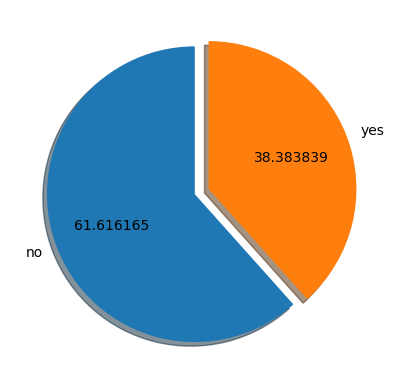



sex
male      577
female    314
Name: count, dtype: int64


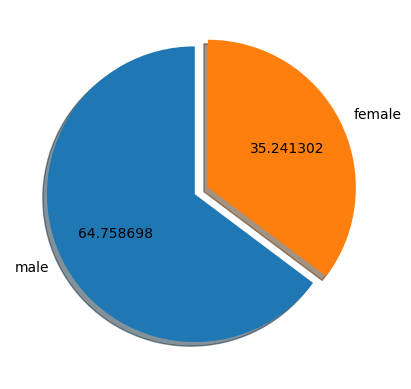



who
man      537
woman    271
child     83
Name: count, dtype: int64


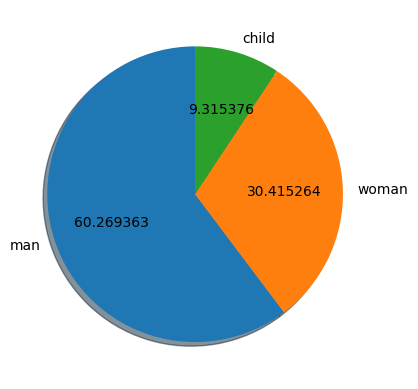



alone
True     537
False    354
Name: count, dtype: int64


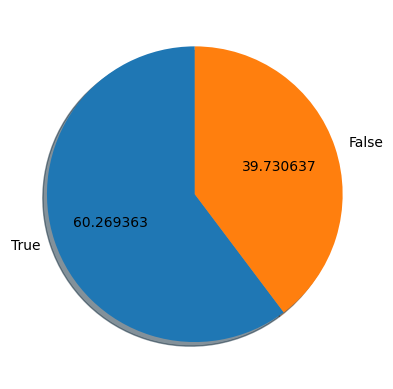

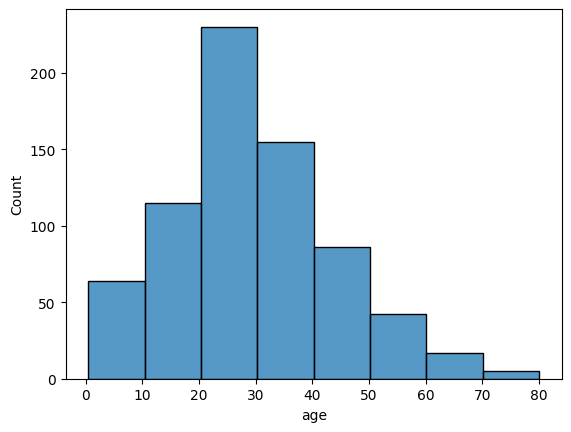

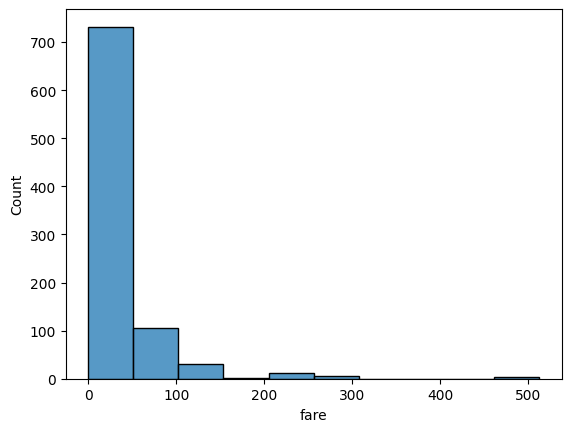

In [9]:
#예제 5-2 데이터에 대한 기본정보
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#타이타닉 데이터 df로 가져오기
df = sns.load_dataset(('titanic'))

#생존자와 사망자 사례 수
print(df["survived"].value_counts())
print(df['alive'].value_counts())

#생존 여부 구성비 <<원그래프로
plt.pie(df['alive'].value_counts(), labels=['no','yes'],
        explode=(0, 0.1), startangle=90, shadow=True, autopct='%1f')
plt.show()

print('\n')

#성별 사례 수 확인
print(df['sex'].value_counts())

#성별 구성비 <<원그래프로
plt.pie(df['sex'].value_counts(), labels=['male','female'],
        explode=(0, 0.1), startangle=90, shadow=True, autopct='%1f')
plt.show()

print('\n')

#성별, 아이별 사례 수
print(df['who'].value_counts())

#성별, 아이별 구성비 (원그래프)
plt.pie(df['who'].value_counts(), labels=['man','woman','child'],
        startangle=90, shadow=True, autopct='%1f' )
plt.show()

print('\n')

#혼자 탑승 여부에 따른 사례 수 와 그래프
print(df['alone'].value_counts())

#혼자 탑승비에 따른 구성비 << 원그래프
plt.pie(df['alone'].value_counts(), labels=['True', 'False'],
        startangle=90, shadow=True, autopct='%1f')
plt.show()

print('\n')

#나이 분포와 요금분포
sns.histplot(df, x='age', bins = 8)
plt.show()

sns.histplot(df, x = 'fare', bins = 10)
plt.show()

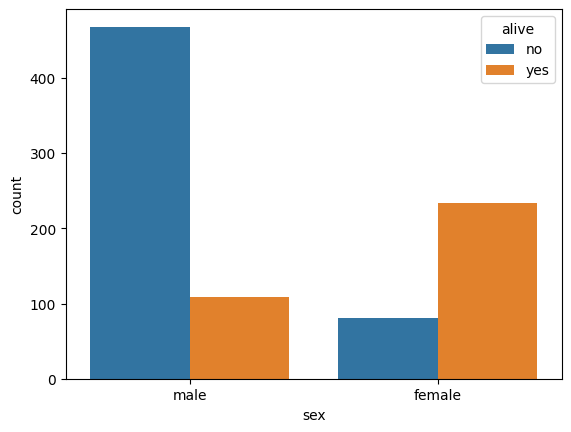

alive    no  yes  All
sex                  
female   81  233  314
male    468  109  577
All     549  342  891




In [10]:
#예제5-3
#성별 생존자 수와 생존율의 비교
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#성별 생존여부
sns.countplot(data=df, x=df['sex'], hue=df['alive'])
plt.show()

#성별 생존 여부에 따른 교차표
print(pd.crosstab(df['sex'], df['alive'], margins=True))
print('\n')

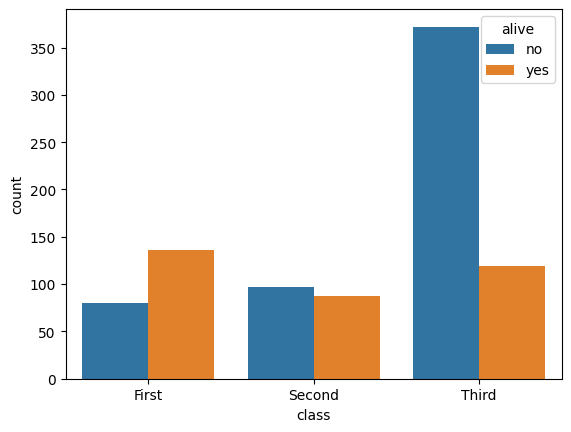

alive    no  yes  All
class                
First    80  136  216
Second   97   87  184
Third   372  119  491
All     549  342  891




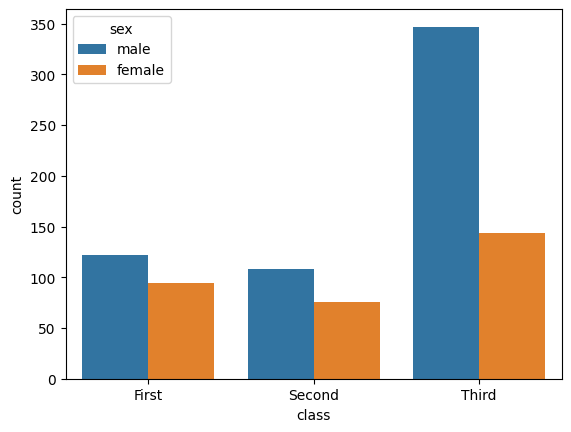

class  First      Second       Third       All
sex   female male female male female male     
alive                                         
no         3   77      6   91     72  300  549
yes       91   45     70   17     72   47  342
All       94  122     76  108    144  347  891
n


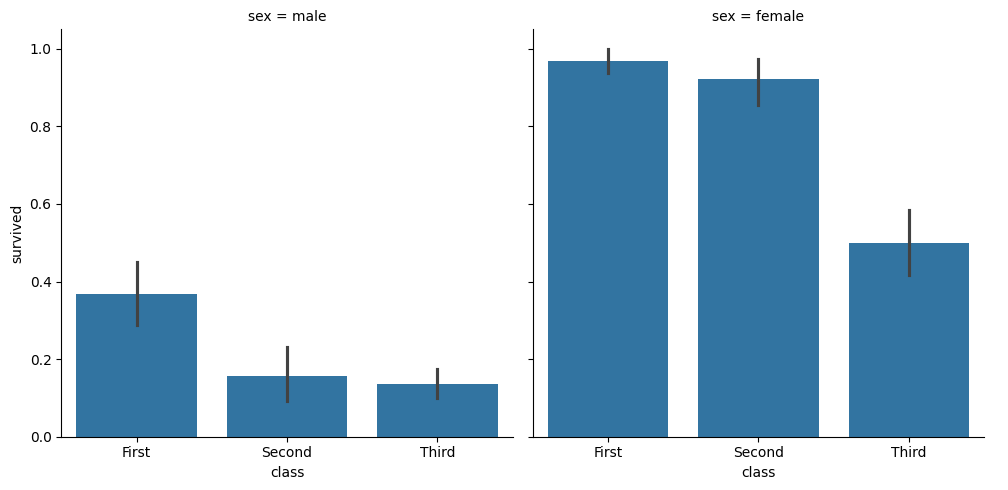

In [14]:
#예제5-4
#객실 등급별 생존자 수와 생존율의 비교
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#객실 등급별 생존여부의 막대그래프
sns.countplot(data=df, x=df['class'], hue = df['alive'])
plt.show()

#객실등급별 생존여부에 따른 교차표
print(pd.crosstab(df['class'], df['alive'], margins=True))
print('\n')

#객실 등급별 성별인원
sns.countplot(data=df, x=df['class'], hue=df['sex'])
plt.show()

#객실등급별 성별에 따른 교차표
#생존여부에 따른 객실등급과 성별의 교차표
print(pd.crosstab(df['alive'], [df['class'], df['sex']], margins=True))
print('n')

#객실등급별 성별 생존율
sns.catplot(x='class', y='survived', col='sex', data=df, kind='bar')
plt.show()

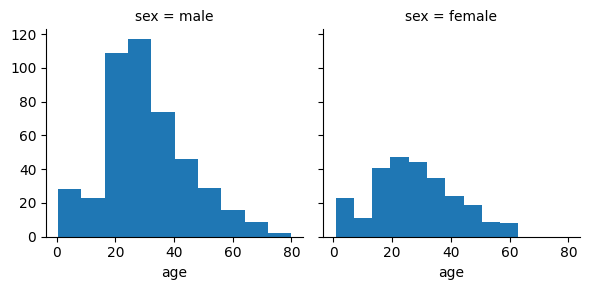

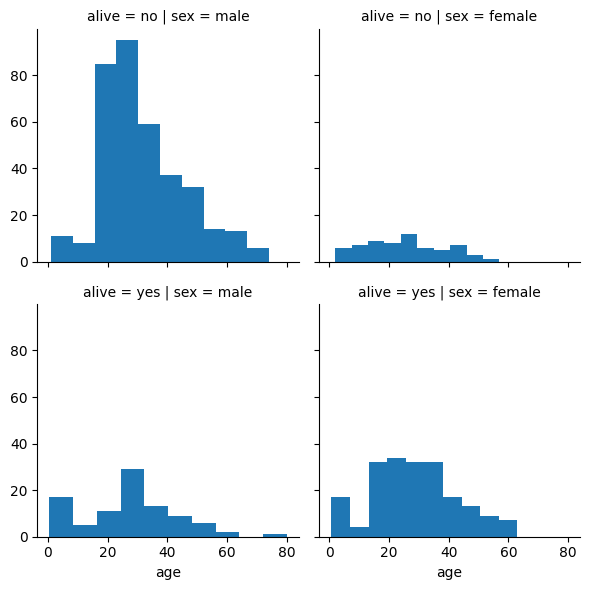

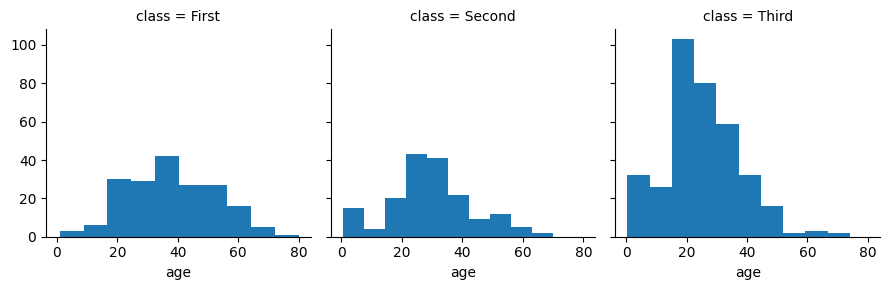

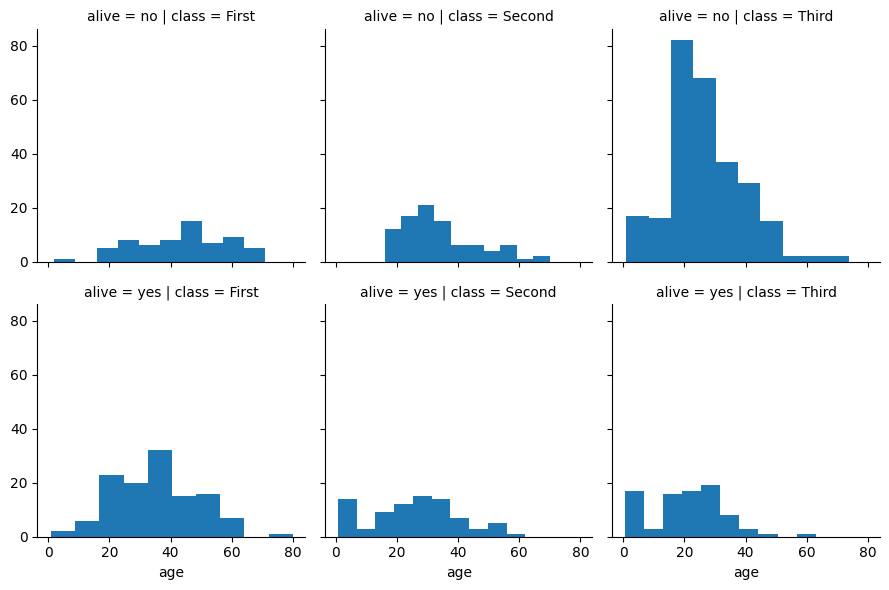

In [15]:
#예제 5-5
#연령별 생존자 수와 생존율의 비교

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#성별에 따른 나이분포
g = sns.FacetGrid(df, col='sex')
g.map(plt.hist, 'age')
plt.show()

#생존여부에 따른 나이분포
g = sns.FacetGrid(df, col='sex', row='alive')
g.map(plt.hist, 'age')
plt.show()

#객실 등급별 나이분포
g = sns.FacetGrid(df, col='class')
g.map(plt.hist, 'age')
plt.show()

#객실 등급별 생존여부에 따른 나이 분포
g = sns.FacetGrid(df, col='class', row='alive')
g.map(plt.hist, 'age')
plt.show()

In [28]:
#워드클라우드 _ 단어를 시각화하기 위해 사용, 빈도수나 중요도에 따라 부각시켜서 나타냄

import os
import glob
f1 = []
for file in glob.glob('*.txt'):
  with open(file, 'r', newline='') as filereader:
    for row in filereader:
      contents = row.split()
      for i in contents:
        contents = i.strip('.').strip(',').strip('')
        f1.append(contents)

f1

['작은',
 '일에',
 '성실한',
 '사람은',
 '큰일에도',
 '성실하고',
 '작은일에',
 '정직하지',
 '못한',
 '사람은',
 '큰일에도',
 '정직하지',
 '못하다',
 '누가복음',
 '16:10',
 '변함없이',
 '서로',
 '사랑하는',
 '이가',
 '친구이며',
 '위급할때',
 '서로',
 '돕는',
 '이가',
 '형제다',
 '잠언',
 '17:17']

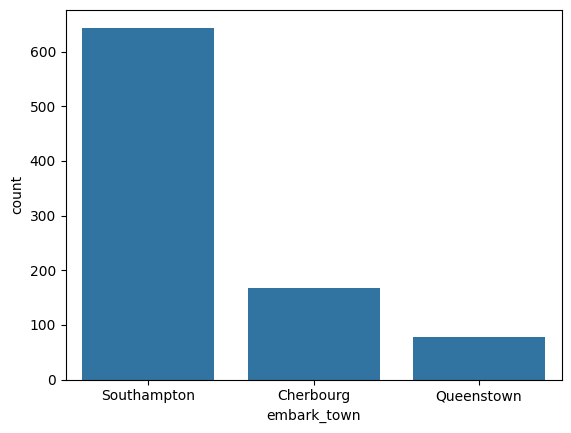

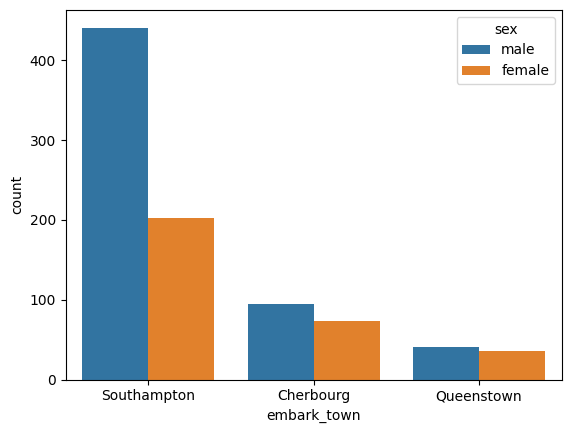

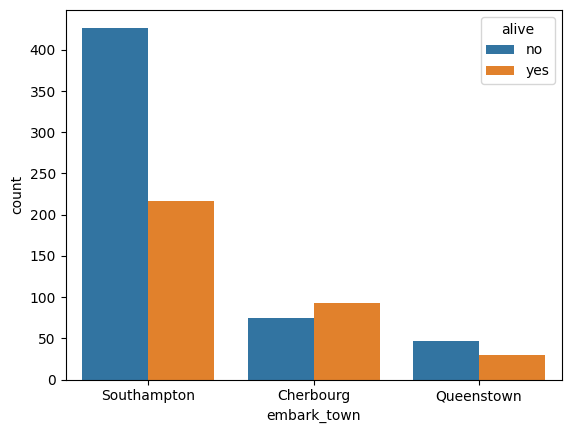

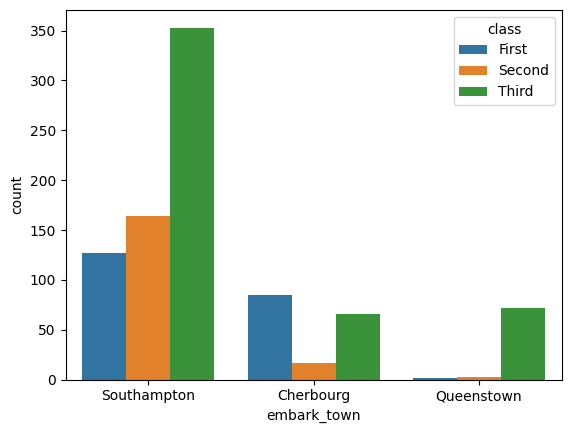

embark_town Cherbourg      Queenstown      Southampton       All
sex            female male     female male      female male     
alive                                                           
no                  9   66          9   38          63  364  549
yes                64   29         27    3         140   77  340
All                73   95         36   41         203  441  889
n
embark_town Cherbourg         Queenstown        Southampton            All
pclass              1   2   3          1  2   3           1    2    3     
alive                                                                     
no                 26   8  41          1  1  45          53   88  286  549
yes                59   9  25          1  2  27          74   76   67  340
All                85  17  66          2  3  72         127  164  353  889


In [16]:
#예제5-6
#탑승도시별 생존자 수와 생존율의 비교

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset(('titanic'))

#도시별 탑승인원
sns.countplot(df, x='embark_town')
plt.show()

#탑승도시별 성별 구분
sns.countplot(df, x = 'embark_town', hue = 'sex')
plt.show()

#탑승도시별 생존여부
sns.countplot(df, x = 'embark_town', hue='alive')
plt.show()

#탑승도시별 등급구분
sns.countplot(df, x = 'embark_town', hue = 'class')
plt.show()

#도시별 성별 생존여부의 사례수
print(pd.crosstab(df['alive'], [df['embark_town'], df['sex']], margins=True))
print('n')

#도시별 등급별 생존여부의 사례수
print(pd.crosstab(df['alive'], [df['embark_town'], df['pclass']], margins=True))

In [36]:
# proverb.txt 저장
contents = """작은 일에 성실한 사람은 큰일에도 성실하고,
작은일에 정직하지 못한 사람은 큰일에도 정직하지 못하다.
누가복음 16:10
변함없이 서로 사랑하는 이가 친구이며
위급할때 서로 돕는 이가 형제다.
잠언 17:17"""

file = open("./proverb.txt", 'w', encoding='utf-8')
file.write(contents)
file.close()  # 괄호 필수!

# hello.txt 입력받아 저장
file = open("./hello.txt", 'a', encoding='utf-8')
while True:
    content = input()
    if not content:
        break
    file.write(content + '\n')
    print(content)
file.close()

# fruits.txt 저장
fruits = ['apple', 'apple', 'apple', 'banana', 'banana', 'orange', 'orange', 'mango', 'orange', 'orange', 'orange']
index = len(fruits)
file = open("./fruits.txt", 'a', encoding='utf-8')
for i in range(index):
    if i < (index - 1):
        file.write(fruits[i] + '\t')
    else:
        file.write(fruits[i] + '\n')
file.close()

나는
나는
똥이다
똥이다
멍멍멍
멍멍멍
개이다
개이다
 
 
그만
그만
ㅇ
ㅇ
ㄷ
ㄷ
ㅈ
ㅈ
ㅂ
ㅂ



In [27]:
#단어 빈도수 구하기 전 준비 _ 마침표, 쉼표, 공백 제거, 사용하지 않는 불용어 제거, 조사, '합니다', '하세요' 제거
import os
import glob

f1 = []
for file in glob.glob('*.txt'):
  with open(file, 'r', newline='') as filereader:
    for row in filereader:
      contents = row.split()
      for i in contents:
        contents = i.strip('.').strip(',').strip('').strip('를').strip('을').strip("''")
        contents = contents.strip('합니다').strip('하세요')
        contents = contents.strip('에')
        f1.append(contents)
f1

['작은',
 '일',
 '성실한',
 '사람은',
 '큰일에도',
 '성실하고',
 '작은일',
 '정직하지',
 '못한',
 '사람은',
 '큰일에도',
 '정직하지',
 '못',
 '누가복음',
 '16:10',
 '변함없이',
 '서로',
 '사랑하는',
 '이가',
 '친구이며',
 '위급할때',
 '서로',
 '돕는',
 '이가',
 '형제',
 '잠언',
 '17:17']

In [30]:
#단어별 갯수 세어 표시하기_ counter 모듈 사용
from collections import Counter
f1
word_counts = Counter(f1)
dict(word_counts)

#word_counts.items()
wc = sorted(word_counts.items(), key=lambda count:count[1], reverse=True)
wc

import pandas as pd
wcdf = pd.DataFrame(wc)
wcdf.columns = ['word', 'freq']

wcdf1 = wcdf.set_index('word')
wcdf1.head()

,freq
word,
사람은,2
큰일에도,2
정직하지,2
서로,2
이가,2


In [31]:
#폰트와 글꼴 설정
import pandas as pd
import numpy as np
import re

#한글표현을 위해서 폰트 설치
%config InlineBackend.figure_format='retina'
!apt -qq -y install fonts-nanum >/dev/null
import matplotlib.font_manager as fm

#프리젠테이션 ttf 사용
fontpath = '/content/Freesentation-5Medium.ttf'
font = fm.FontProperties(fname=fontpath, size=9)

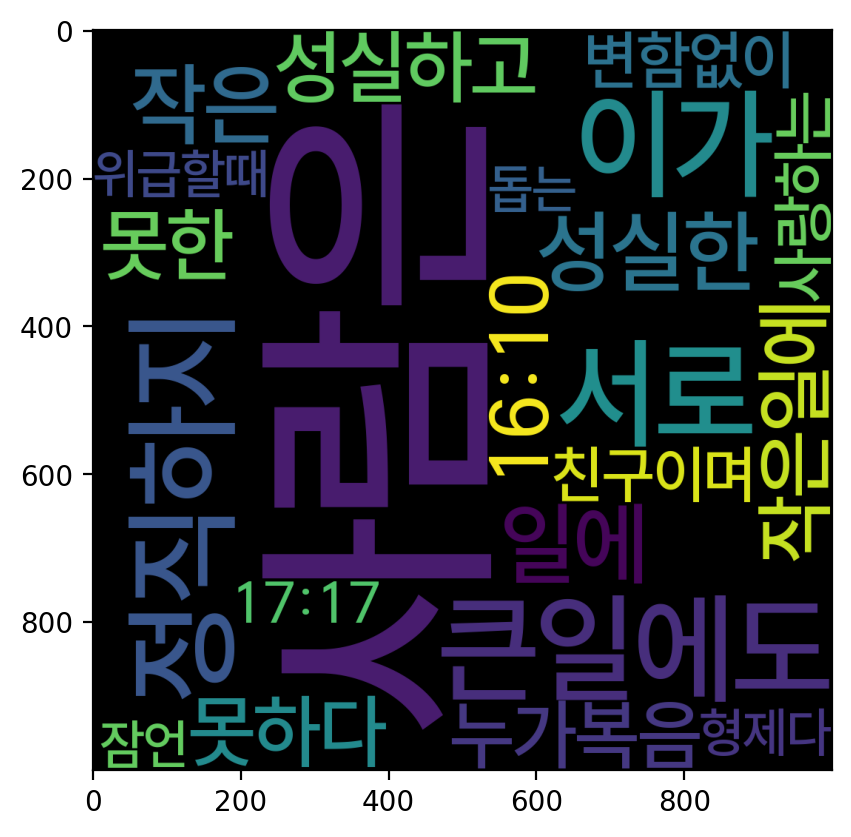

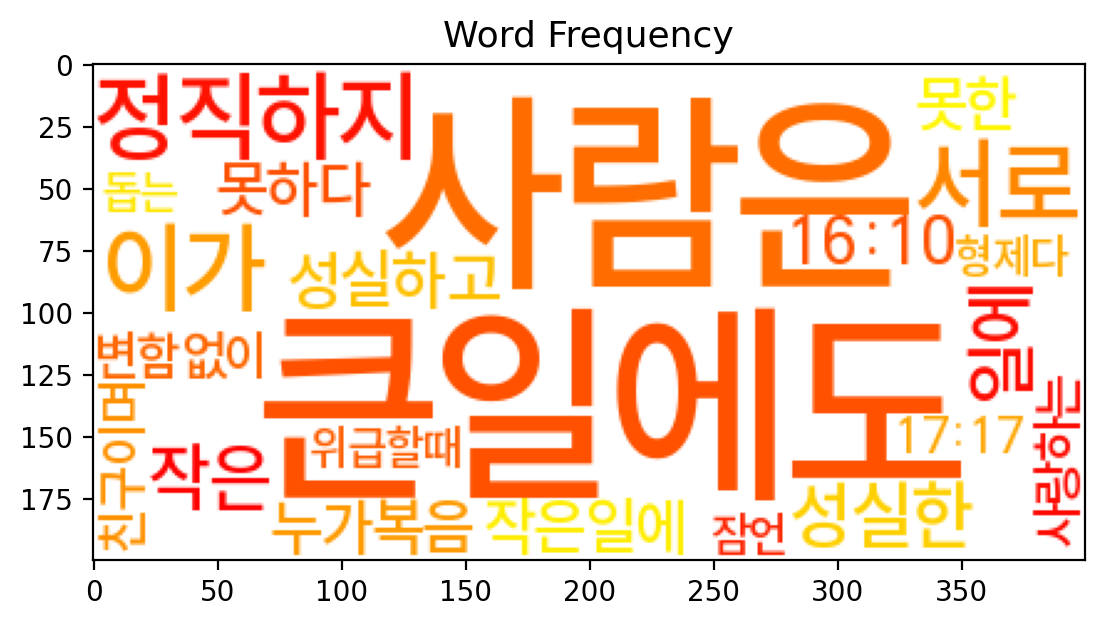

In [38]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

word_freq=wcdf1['freq'].to_dict()
wordcloud=WordCloud(font_path='/content/Freesentation-5Medium.ttf', width=1000,height=1000).generate_from_frequencies(word_freq)

plt.imshow(wordcloud)
plt.show()

wordcloud = WordCloud(font_path='/content/Freesentation-5Medium.ttf',
                     background_color='white', colormap='autumn').generate_from_frequencies(word_freq)

plt.imshow(wordcloud)
plt.title('Word Frequency', size=13) #제목지정
plt.show()

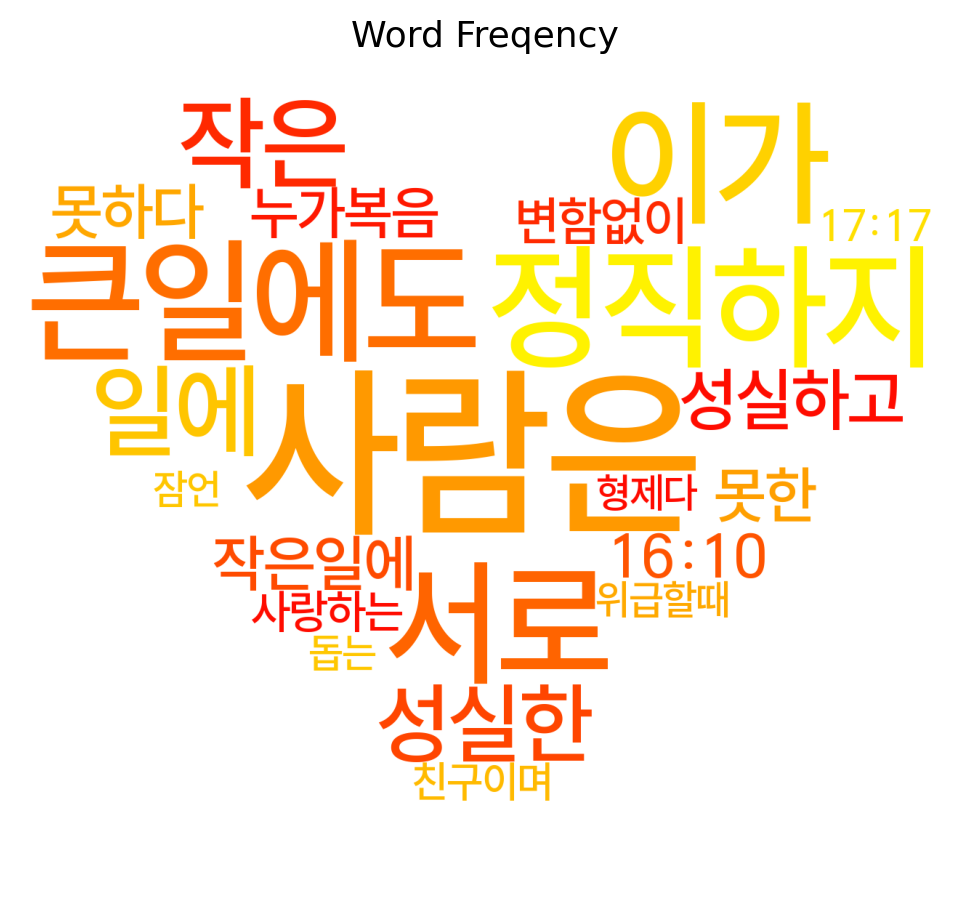

In [39]:
from PIL import Image
import numpy as np
im = Image.open('/content/heart.png')
mask_arr = np.array(im)

wordcloud = WordCloud(font_path='/content/Freesentation-5Medium.ttf',
                      background_color='white', colormap='autumn',
                      width=700, height=700, random_state = 43,
                      mask = mask_arr, prefer_horizontal=True).generate_from_frequencies(word_freq)

plt.figure(figsize=(6, 6))
plt.imshow(wordcloud)
plt.title('Word Freqency', size=13)
plt.axis('off')
plt.show()

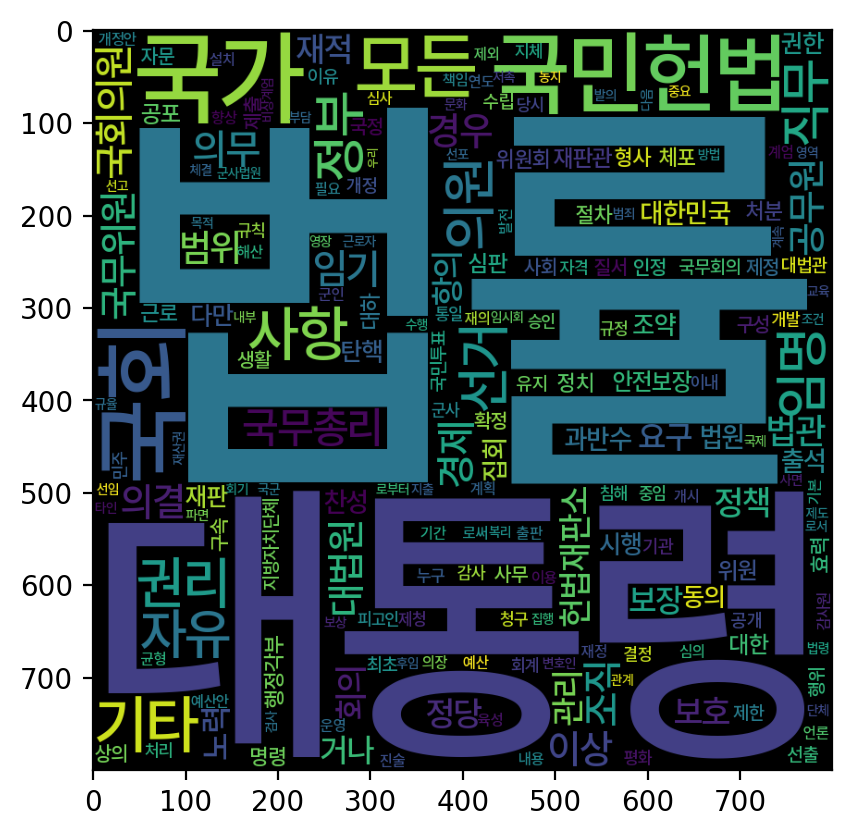

In [41]:
from http.client import OK
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from konlpy.tag import Okt
import numpy as np

#텍스트 분석하기
with open('/content/대한민국헌법(헌법).txt', 'r' , encoding='cp949') as f:text = f.read()
okt = Okt()
nouns = okt.nouns(text)
words = [n for n in nouns if len(n)>1]
c = Counter(words)

#워드클라우드 생성하기
wc = WordCloud(font_path='/content/Freesentation-5Medium.ttf', width=400, height=400, scale=2.0,
               max_font_size=250)
gen = wc.generate_from_frequencies(c)

plt.figure()
plt.imshow(gen)
wc.to_file('헌법_워드클라우드.png')

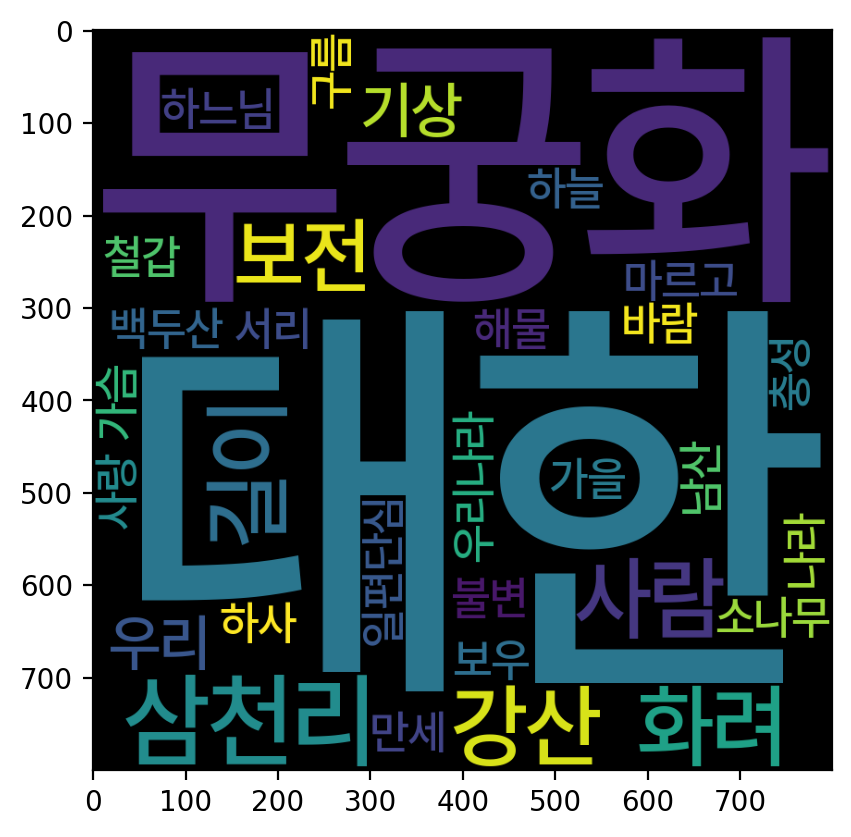

In [43]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from konlpy.tag import Okt
import numpy as np

#파일에서 텍스트를 읽어와 분석.
#텍스트를 형태소로 분리하고 빈도수를 c에 저장
with open('/content/애국가.txt', 'r', encoding='utf-8') as f:
  text = f.read()
  okt = Okt()
  nouns = okt.nouns(text)
  words = [n for n in nouns if len(n) > 1]
  c = Counter(words)

#워드클라우드 객체를 생성하고 빈도수가 큰 단어가 크게 나타나도록 워드클라우드를 그리기
wc = WordCloud(font_path='/content/Freesentation-5Medium.ttf', width=400, height=400, scale=2.0, max_font_size=250)
gen = wc.generate_from_frequencies(c)

plt.figure()
plt.imshow(gen)

wc.to_file('애국가_워드클라우드.png')

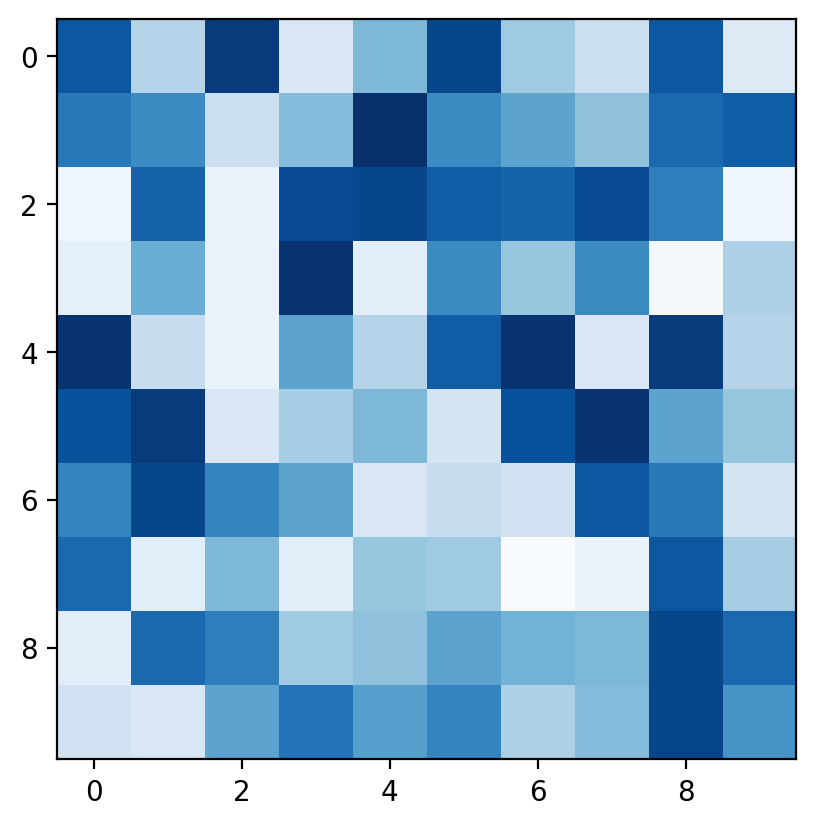

In [46]:
#히트맵 구현하는 방법

import matplotlib.pyplot as plt
import numpy as np

#재현성을 위한 시드 생성
np.random.seed(2)
#1-50사이의 정수로 구성된 10*10배열 생성
data = np.random.randint(low=1, high=50, size=(10,10))
#데이터를 시각화하기 위한 imshow()
plt.imshow(data, cmap='Blues')

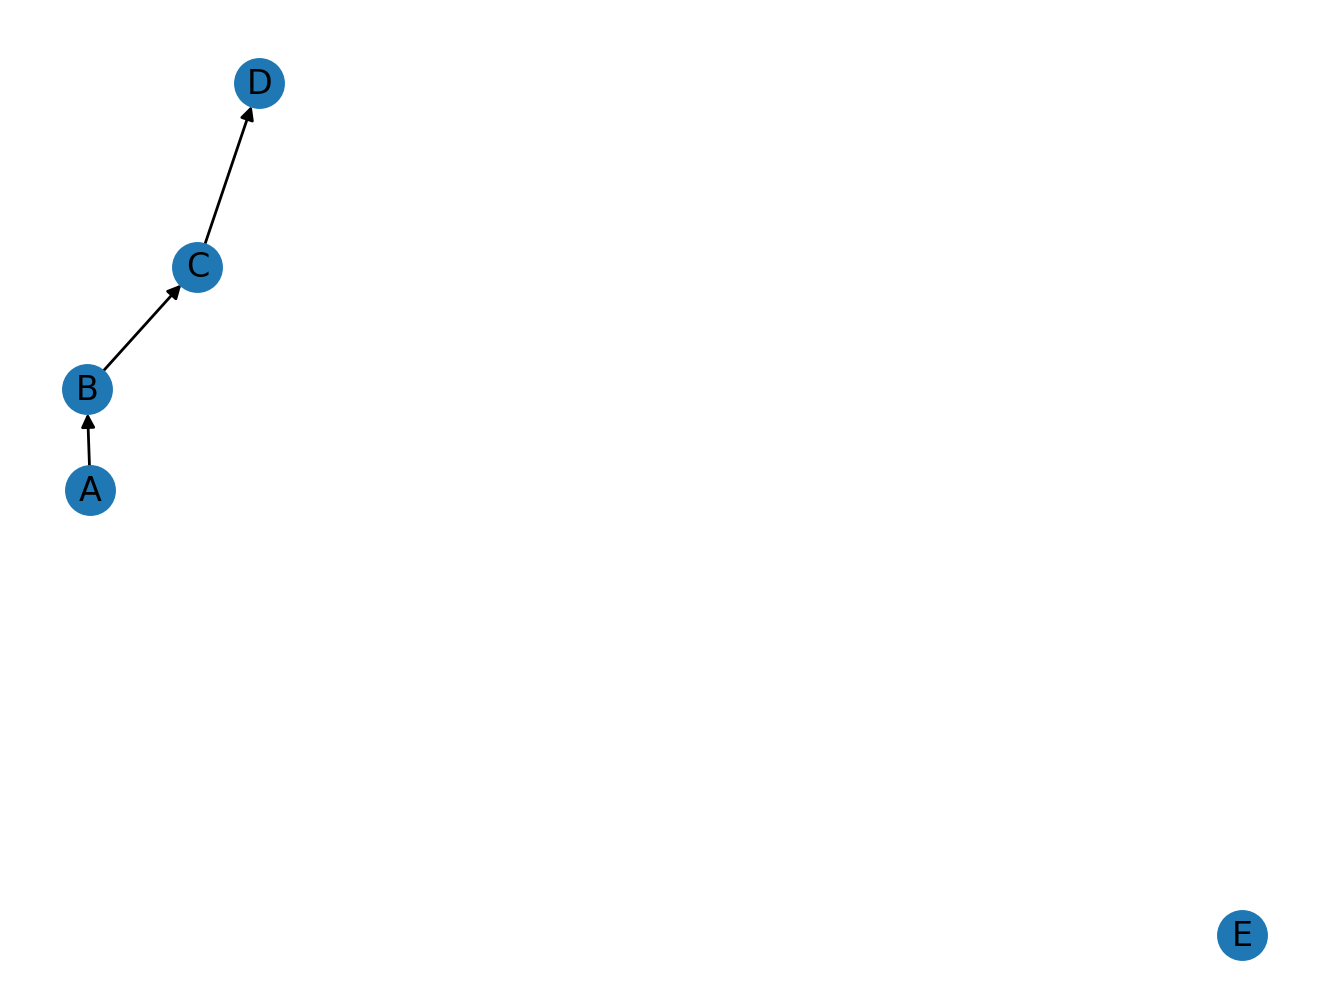

In [51]:
#네트워크 다이어그램 만들기
!pip install networkx

import networkx as nx

G = nx.DiGraph()
G.add_nodes_from(['A','B','C','D','E'])
G.add_edges_from([('A','B'),('B','C'),('C','D')])

nx.draw(G, with_labels=True)


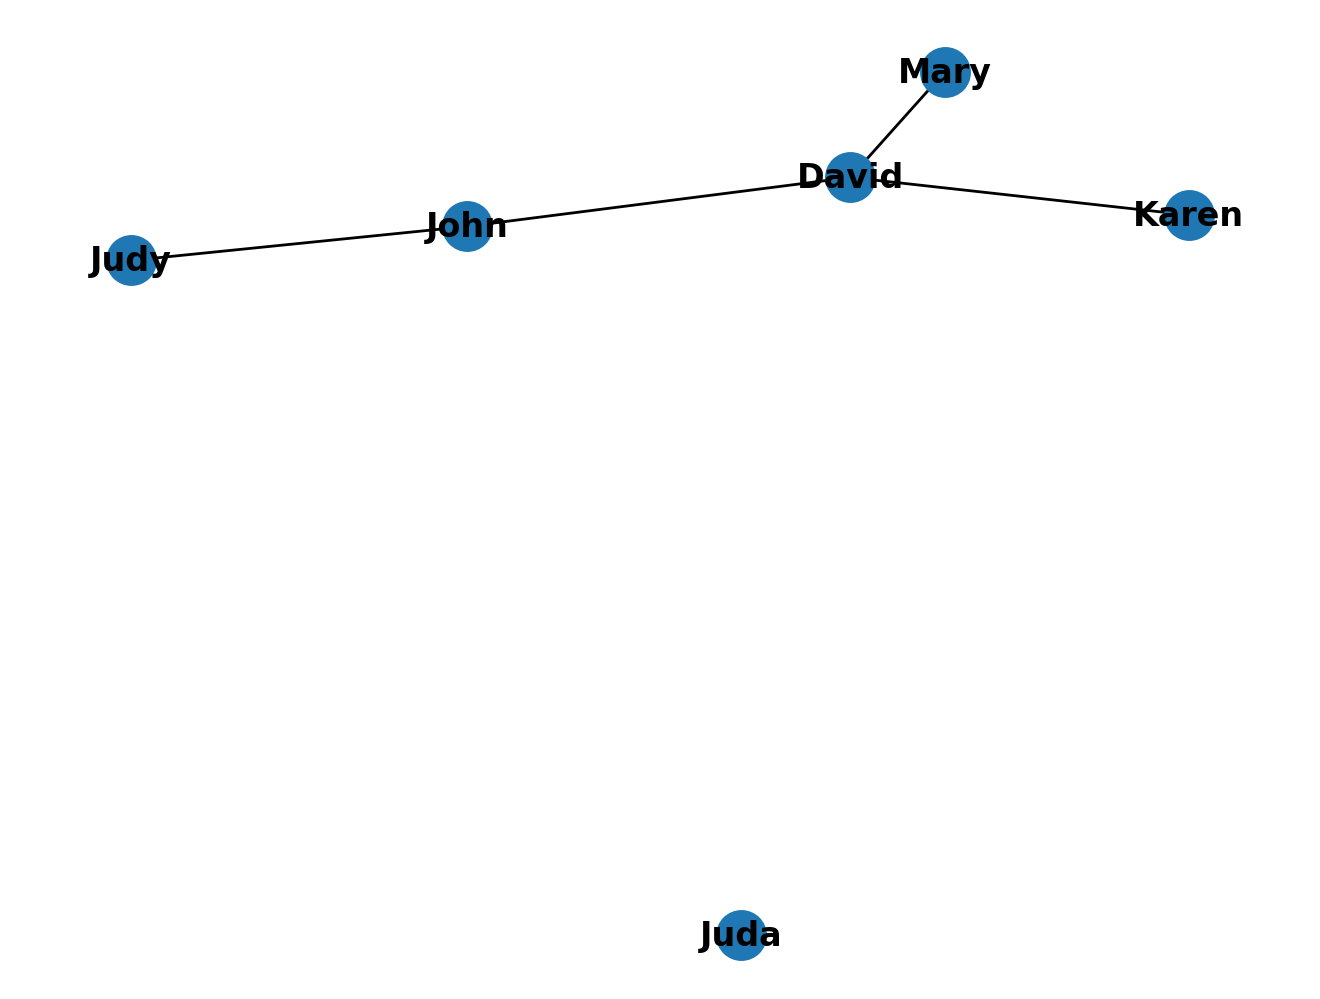

In [52]:
#노드 추가 및 제거하기
g1 = nx.Graph()
g1.add_node('David')
g1.add_node('John')
g1.add_node('Mary')
g1.add_node('Julia')
g1.add_node('Juda')
g1.add_nodes_from(['Judy','Karen'])
g1.remove_node('Julia')

#선 추가 및 제거하기
g1.add_edge('David','John')
g1.add_edge('David','Mary')
g1.add_edge('David','Karen')
g1.add_edges_from([('John','Mary'),('John','Judy')])
g1.remove_edge('Mary','John')

nx.draw(g1, with_labels=True, font_weight='bold')

NodeView(('David', 'John', 'Mary', 'Juda', 'Judy', 'Karen'))

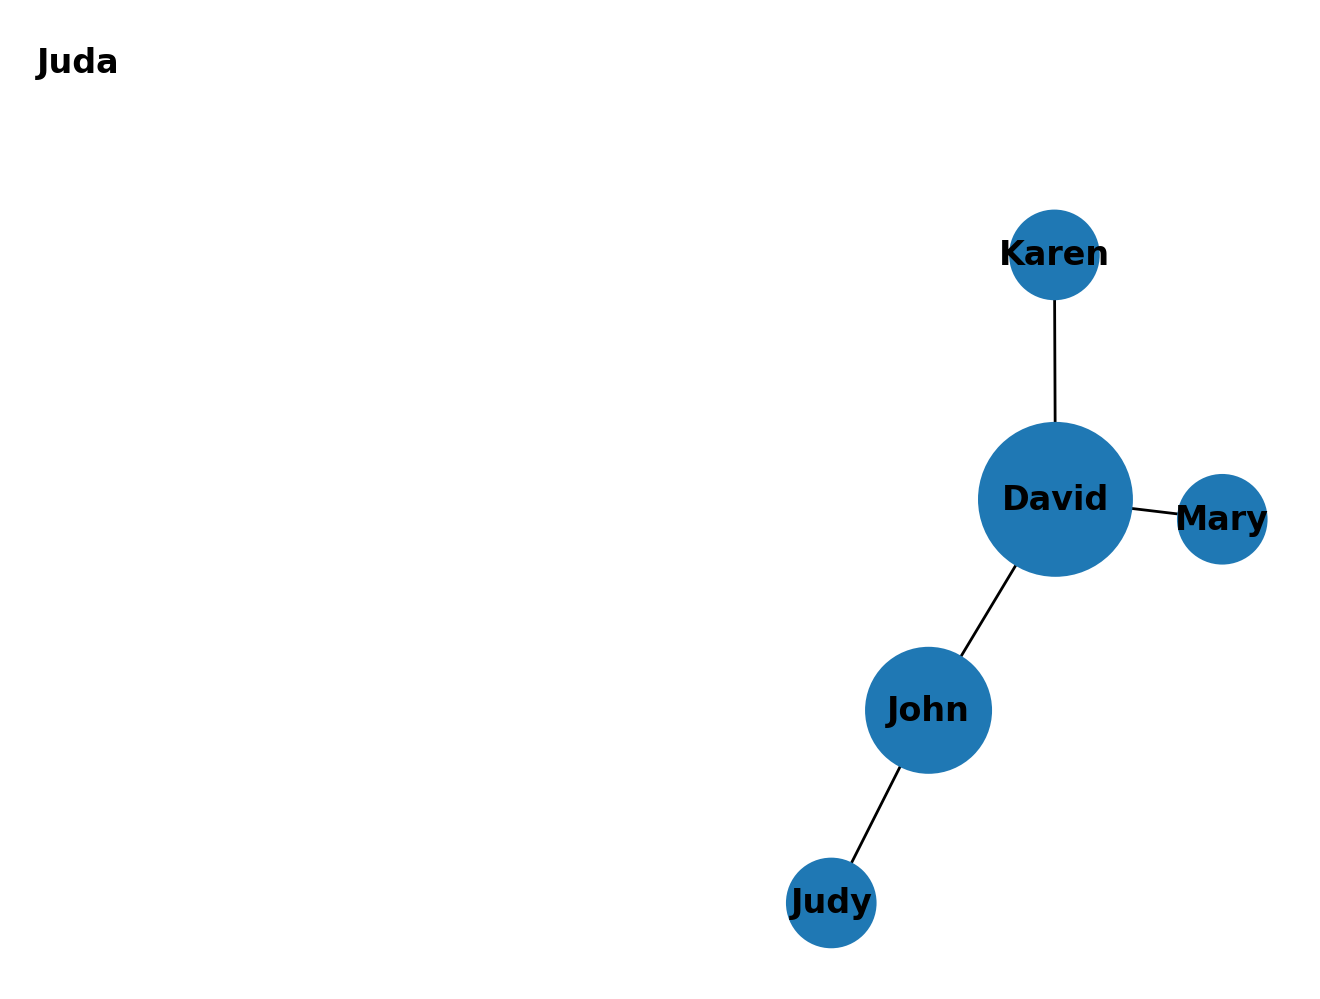

In [53]:
#노드 크기를 차수에 비례하게 설정
d = dict(g1.degree)
nx.draw(g1, nodelist=d.keys(), node_size=[v*1000 for v in d.values()], with_labels=True, font_weight='bold')

g1.nodes

[(1, 0), (2, 1), (3, 1), (4, 2)]
[(1, 3), (2, 0), (3, 1), (4, 0)]


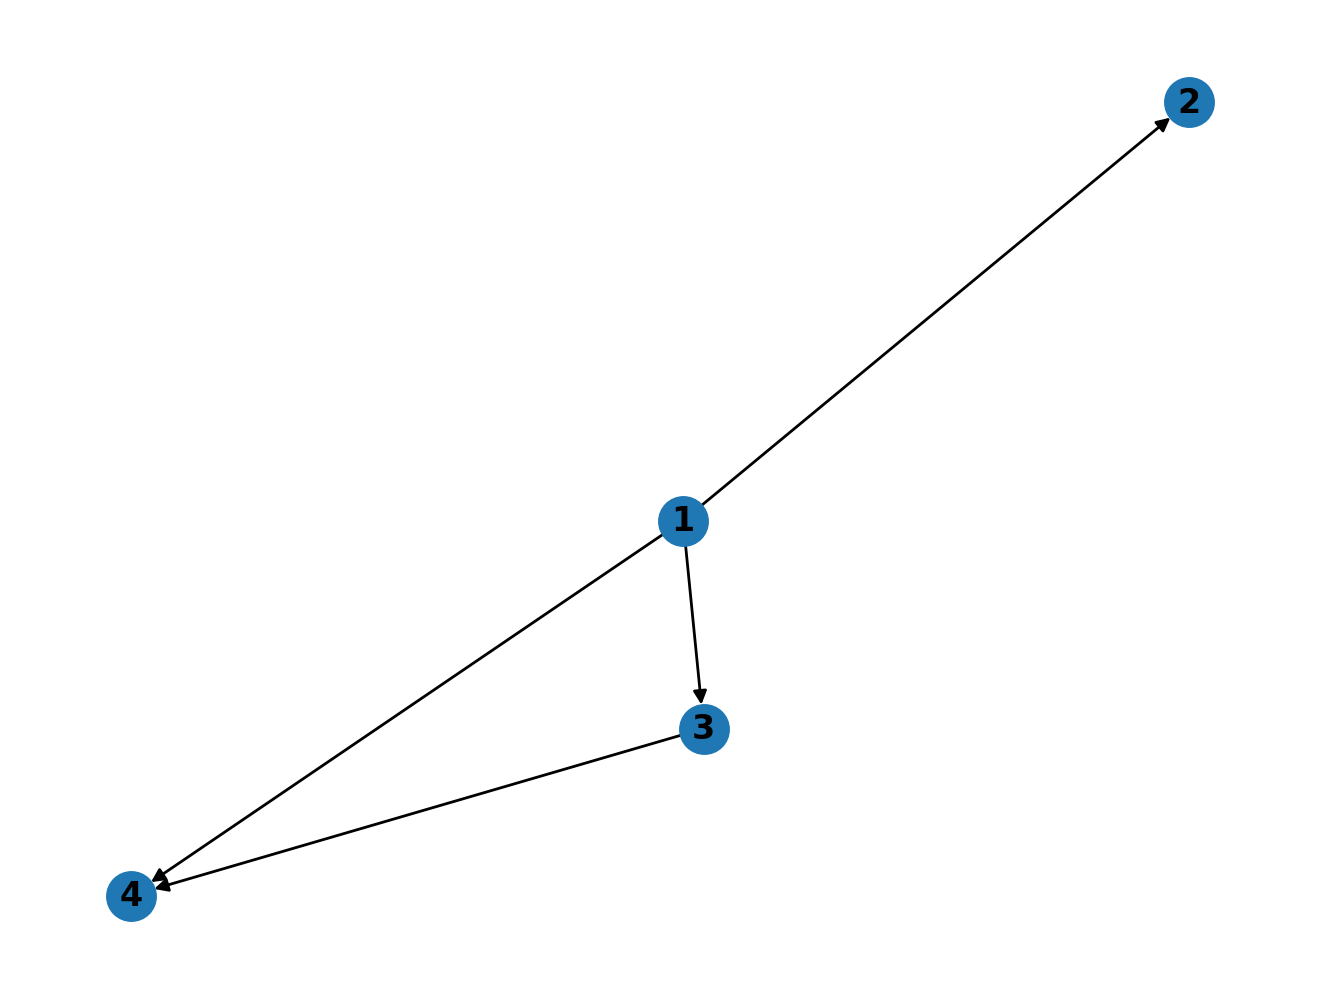

In [54]:
#방향성 그래프

g2 = nx.DiGraph()
g2.add_edges_from([(1,2),(1,3),(1,4),(3,4)])
nx.draw(g2, with_labels=True, font_weight='bold')

print(g2.in_degree)
print(g2.out_degree)

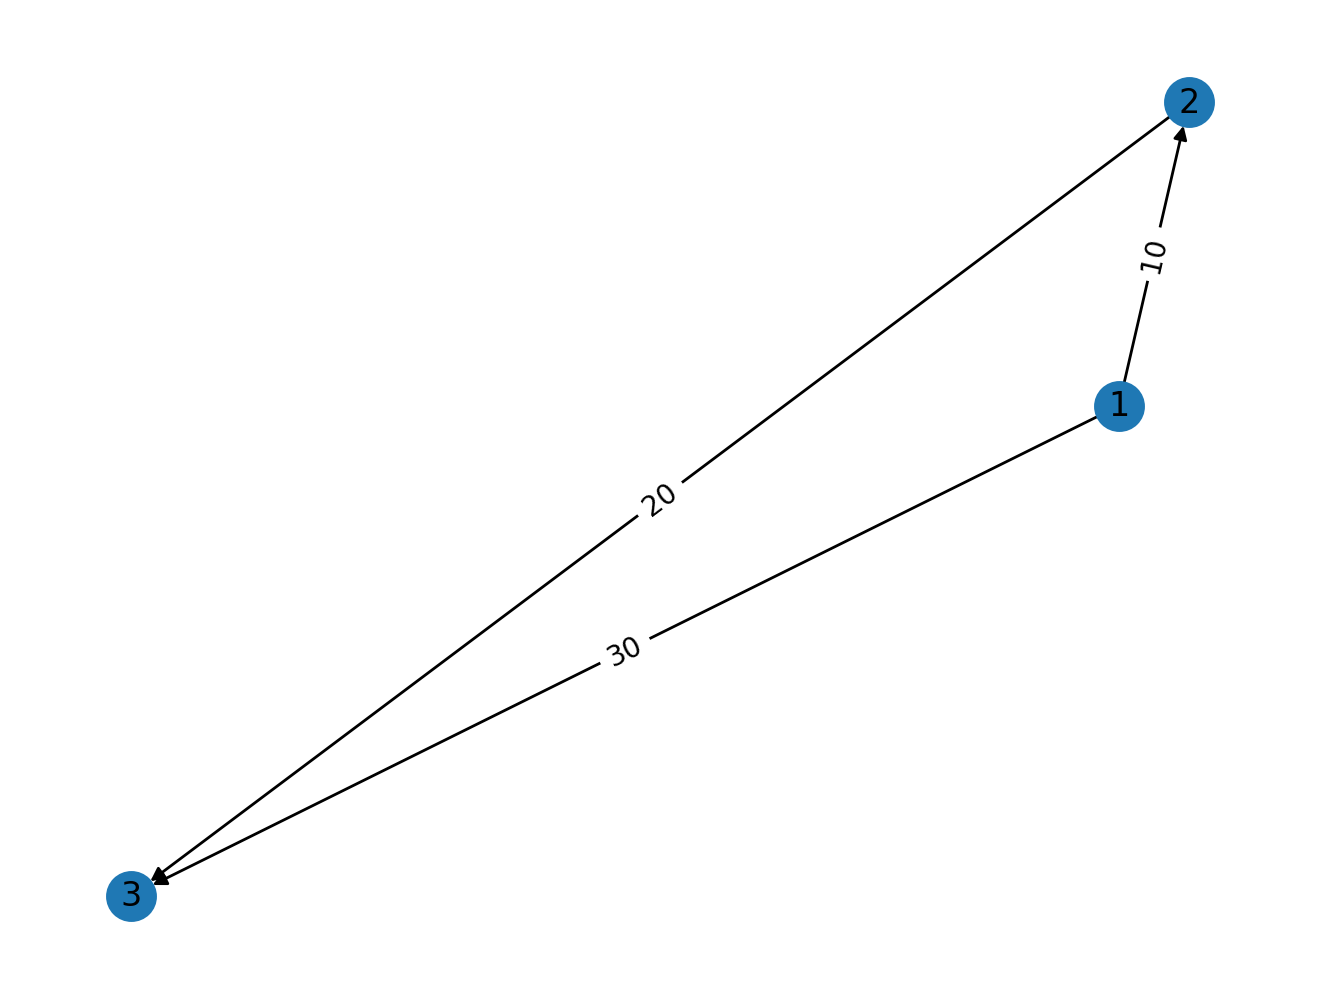

In [55]:
#가중치 표시
g3 = nx.DiGraph()
g3.add_weighted_edges_from([(1,2,10),(2,3,20)])
g3.add_edge(1,3, weight=30)
pos = nx.spring_layout(g3)

nx.draw(g3, pos=pos, with_labels=True)
labels = nx.get_edge_attributes(g3, 'weight')
nx.draw_networkx_edge_labels(g3, pos, edge_labels=labels);

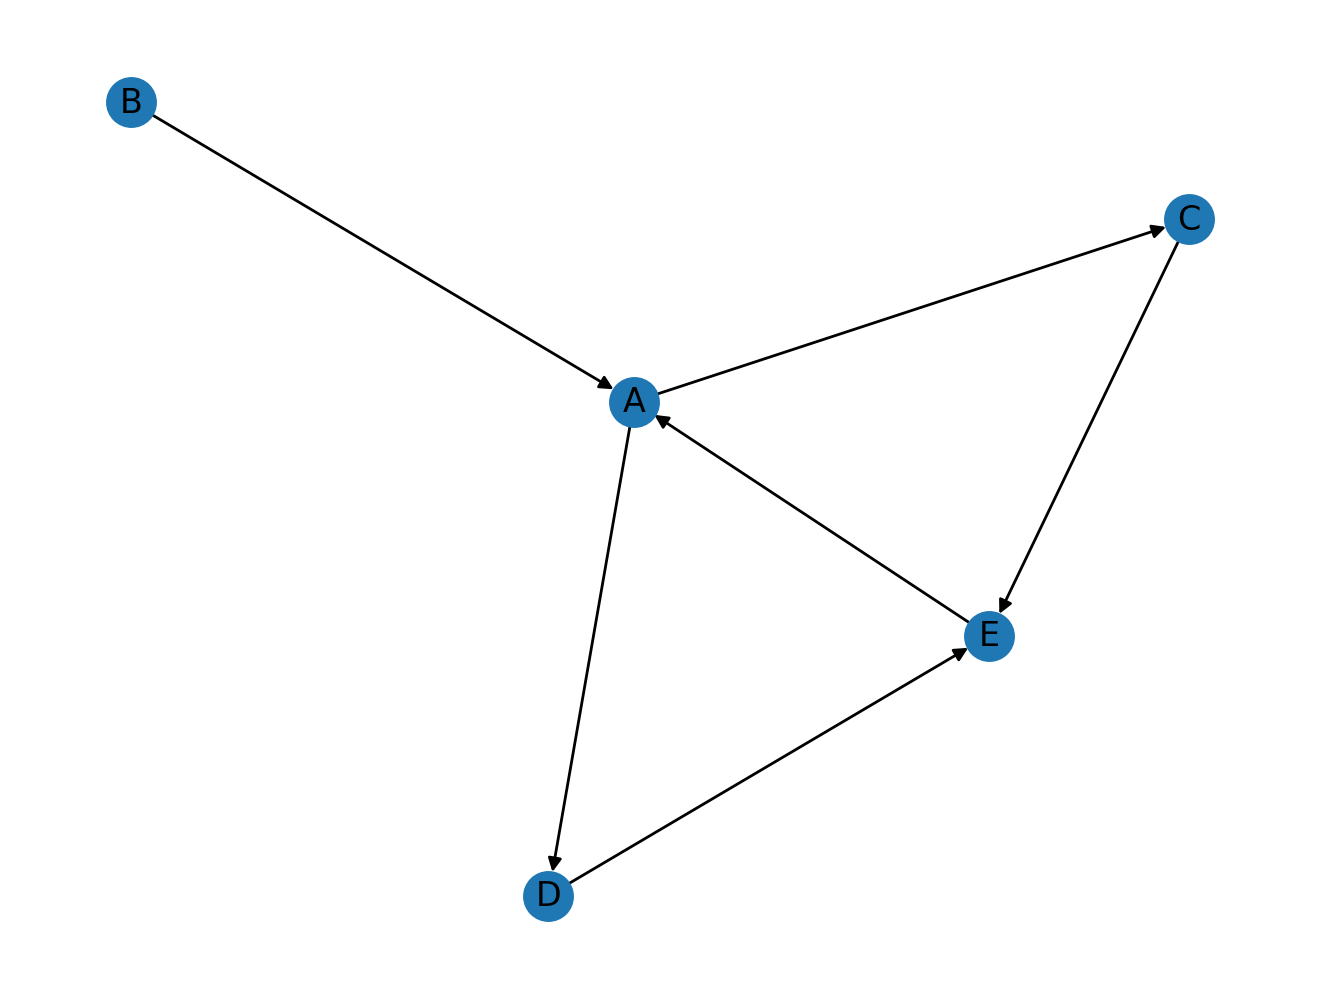

In [56]:
#판다스 데이터프레임 활용
#선의 시작점과 끝점, 가중치데이터를 데이터 프레임을 구성하여 네트워크 그래프로 변환
import pandas as pd
df = pd.DataFrame({'from':['A','B','C','A','E','D'],
                   'to': ['D','A','E','C','A','E'],
                   'weight': [1,2,3,4,5,6]})
g4 = nx.from_pandas_edgelist(df, 'from', 'to', create_using=nx.DiGraph())
nx.draw(g4, with_labels=True)

In [57]:
#튀르키에 뉴스 시각화
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [70]:
#튀르기예 뉴스 시각화
#라이브러리 불러오고 파일 열기
#텍스트 데이터 분석을 위한 라이브러리를 모두 불러오기
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import networkx as nx
from konlpy.tag import Hannanum

hannanum = Hannanum()

#파일을 열어서 텍스트 읽기
f = open('/content/News.csv', 'r', encoding='cp949')
lines = f.readlines()
print(lines)
f.close()

#명사 추출 : nouns() 함수를 사용
#텍스트에서 명사만 추출
dataset = []
for i in range(len(lines)):
  dataset.append(hannanum.nouns(re.sub('[^가-힣a-zA-Z\s]','',lines[i])))
dataset[:3]

['“튀르키예에 힘 보태자” 온정이 한가득 쌓였다\n', '"튀르키예 강진, 우리나라 지하수 수위에도 영향"\n', '“부실 공사가 피해 더 키워” 불법 건축과 싸운 도시는 멀쩡\n', '일부 지역 구조 종료 “‘생존자 지원’으로 방향 전환”\n', "땅이 미친듯이 들썩였다 CCTV에 찍힌 '대지진 공포'\n", '시리아 국경지대 가보니 530만 명 거처 잃어 “최악 경험”\n', '"인천공항공사, 튀르키예 지진 피해 긴급구호금 지원"\n', '"“가짜뉴스로 기도할 뻔 ” 재난 악용, 모금 유도하는 가짜뉴스 주의"\n', '희망 버려선 안 되는 이유 9일째에도 ‘생존자가 증명하기에’\n', '시리아 들어간 구호 트럭 52대뿐 늦어도 너무 늦었다\n', '주한 대사관 “중고품 기증 사양” 소독 후 보내기엔 시간 촉박\n', '"13살 소년 182시간 만에 구조...""사망 3만7천명 넘어"""\n', '튀르키예 지진 사망 4만 명 근접...구호 주력\n', '사망 3만7000명 넘어 ‘생존자 지원’ 초점[튀르키예 시리아 대지진 현장을 가다]\n', '카타르 월드컵 ‘컨테이너 숙소’ 1만호 튀르키예로\n', '[뉴스9 헤드라인]\n', '“튀르키예 현장? 자세히보니 소름 돋는다” 가짜 후원 SNS 주의보\n', '지진 발생 198시간 만에 3명 기적 생환 생존자 ‘2차 재난’ 촉각\n', '튀르키예 시리아 강진 충북 곳곳서 ‘후원 물결’\n', '“해남매일시장 청년 공략 활성화 방안 마련해야”\n', '[여적] 종이학과 구호품\n', '발 찔리고 목숨 잃어도 튀르키예 파견 구조견의 투혼\n', '"튀르키예 흔들릴 때 7,400km 떨어진 문경서도 \'출렁\'"\n', '"[현장] ""시신 찾을 때까지"" 고통 속에서 버티는 생존자"\n', "튀르키예 강진에 7천km 떨어진 우리나라 지하수 수위 '출렁'\n", '"""네 발의 영웅들"" 구조견 작업 중 사망에 붕대투혼까지"\n', '하늘과 길에서 본 지진 피해 원상복구 막막\n', "'하얀헬멧'도 멈췄다 시리아의 

[['튀르키예', '힘', '보태', '온정', '한가득'],
 ['튀르키예', '강진', '우리나라', '지하수', '수위', '영향'],
 ['부', '공사', '불법', '것', '축', '도시', '멀쩡']]

In [71]:
#연관규칙 분석
#apyori 라이브러리를 사용하여 튀르키예 뉴스에서 추출한 명사 간 연관 규칙 분석.

!pip install apyori
from apyori import apriori

#연관규칙 데이터프레임 생성하기
result = (list(apriori(dataset, min_support=0.01)))
df = pd.DataFrame(result)

#항목 수가 2인 것만 남기기
df['lenth'] = df['items'].apply(lambda x:len(x))
df = df[(df['lenth']==2)&(df['support']>=0.01)].sort_values(by='support', ascending=False)

df.head(3)

,items,support,ordered_statistics,lenth
139,"(지진, 튀르키예)",0.128978,"[((), (지진, 튀르키예), 0.12897847832676568, 1.0), (...",2
133,"(튀르키예, 시리아)",0.092301,"[((), (튀르키예, 시리아), 0.09230069718096393, 1.0), ...",2
80,"(튀르키예, 강진)",0.086693,"[((), (튀르키예, 강진), 0.08669293725371324, 1.0), (...",2


In [72]:
!pip install scipy # ==1.80
!pip install pyg-nightly

In [86]:
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False # This line is to prevent break in character

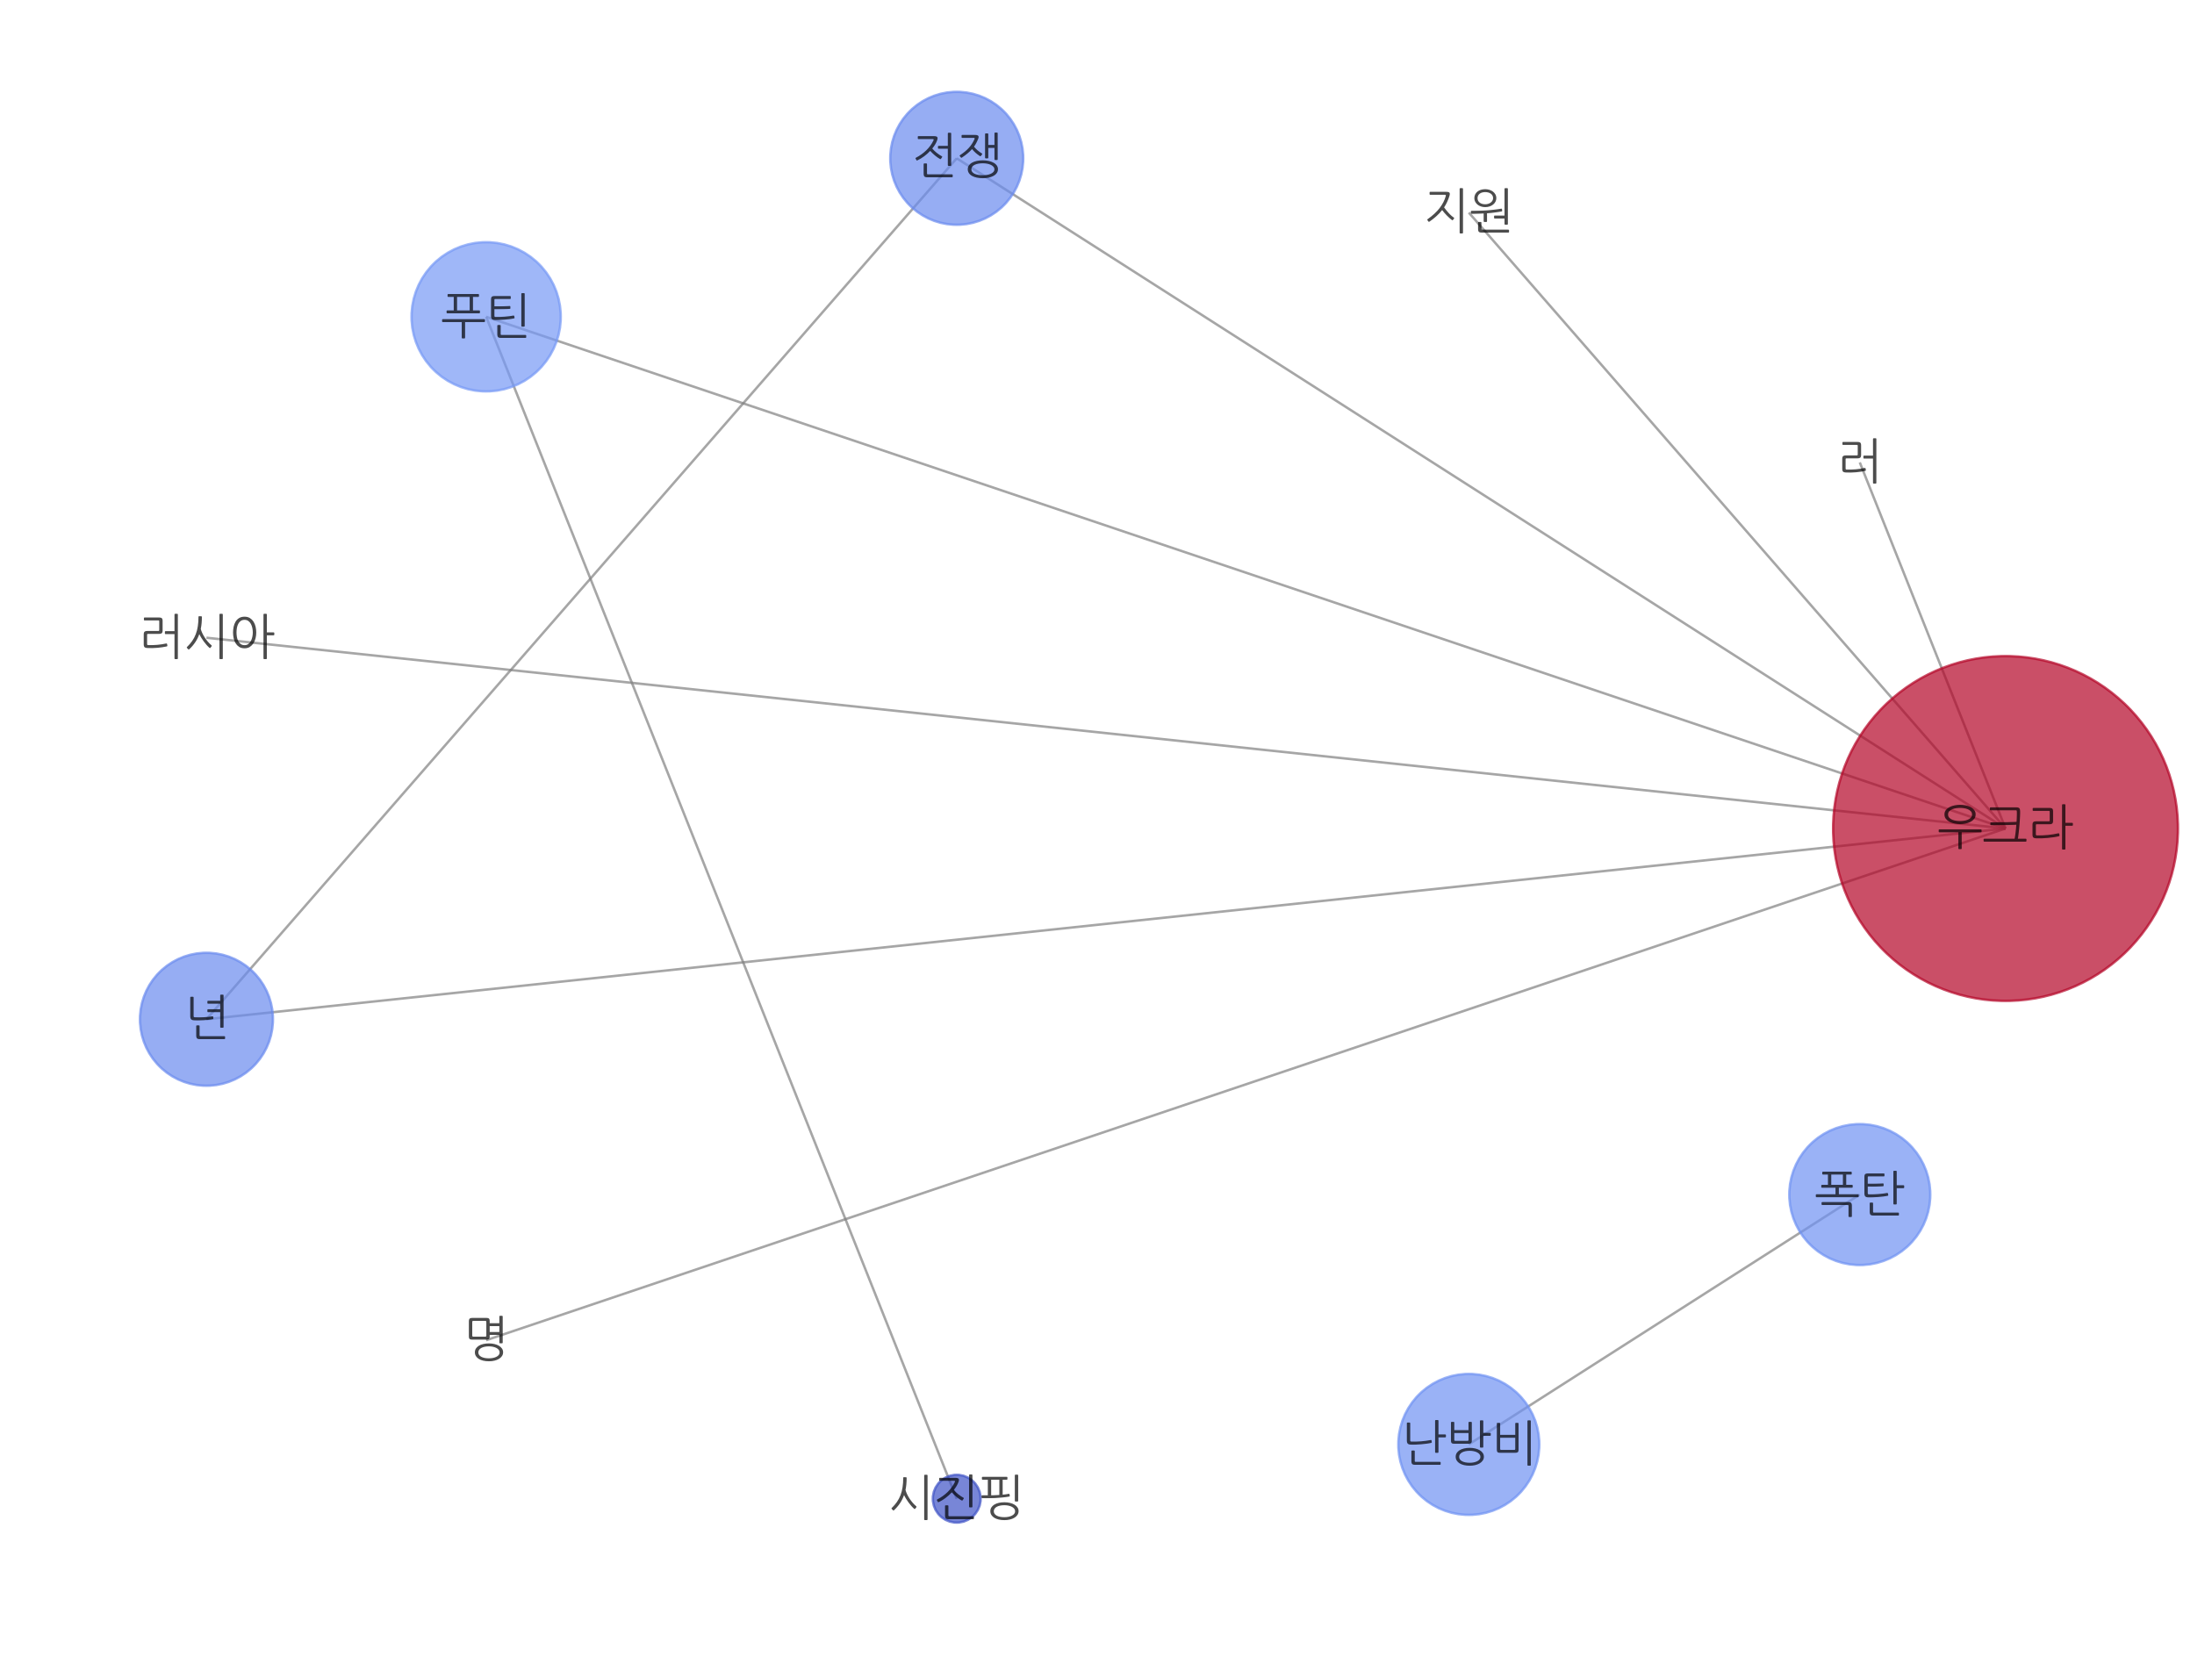

In [96]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np

G = nx.Graph()
ar = (df['items']); G.add_edges_from(ar)
pr = nx.pagerank(G)
nsize = np.array([v for v in pr.values()])
nsize = 2000 * (nsize-min(nsize)) / (max(nsize)-min(nsize))
pos = nx.circular_layout(G)
plt.figure(figsize=(16,12)); plt.axis('off')
nx.draw_networkx(G, font_family='NanumGothic', font_size=20, pos=pos,\
                 node_color=list(pr.values()), node_size=nsize*10, alpha=0.7,
                 edge_color='.5', cmap=plt.cm.coolwarm)
plt.savefig('Img.png', bbox_inches='tight')

In [81]:
#우크라이나 뉴스 시각화

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import networkx as nx
from konlpy.tag import Hannanum

hannanum = Hannanum()

#한글폰트 설치 후 라이브러리 불러오기
f = open('/content/우크라이나.csv','r',encoding='cp949')
lines = f.readlines()
f.close()

dataset = []
for i in range(len(lines)):
  dataset.append(hannanum.nouns(re.sub('[^가-힣a-zA-Z\s]','',lines[i])))
dataset[:3]

#연관규칙분석 알고리즘 apriori 로 가능성이 높은 연관규칙만 계산하도록 필터링.
from apyori import apriori

result = (list(apriori(dataset, min_support=0.01)))
df = pd.DataFrame(result)

df['length'] = df['items'].apply(lambda x: len(x))
df = df[(df['length']==2)&(df['support'] >= 0.01)].sort_values(by='support', ascending=False)
df

,items,support,ordered_statistics,length
74,"(우크라, 러)",0.034669,"[((), (우크라, 러), 0.03466919346747673, 1.0), ((러...",2
79,"(우크라, 지원)",0.029708,"[((), (우크라, 지원), 0.029708488935956748, 1.0), (...",2
78,"(우크라, 전쟁)",0.028092,"[((), (우크라, 전쟁), 0.02809207959422552, 1.0), ((...",2
80,"(우크라, 푸틴)",0.014102,"[((), (우크라, 푸틴), 0.014101778050275904, 1.0), (...",2
75,"(우크라, 러시아)",0.013377,"[((), (우크라, 러시아), 0.013377180759155009, 1.0), ...",2
73,"(년, 전쟁)",0.012318,"[((), (년, 전쟁), 0.012318153949055237, 1.0), ((년...",2
76,"(우크라, 명)",0.011649,"[((), (우크라, 명), 0.011649294911097487, 1.0), ((...",2
77,"(시진핑, 푸틴)",0.011092,"[((), (시진핑, 푸틴), 0.011091912379466027, 1.0), (...",2
72,"(우크라, 년)",0.010256,"[((), (우크라, 년), 0.01025583858201884, 1.0), ((년...",2
71,"(난방비, 폭탄)",0.010200,"[((), (난방비, 폭탄), 0.010200100328855693, 1.0), (...",2


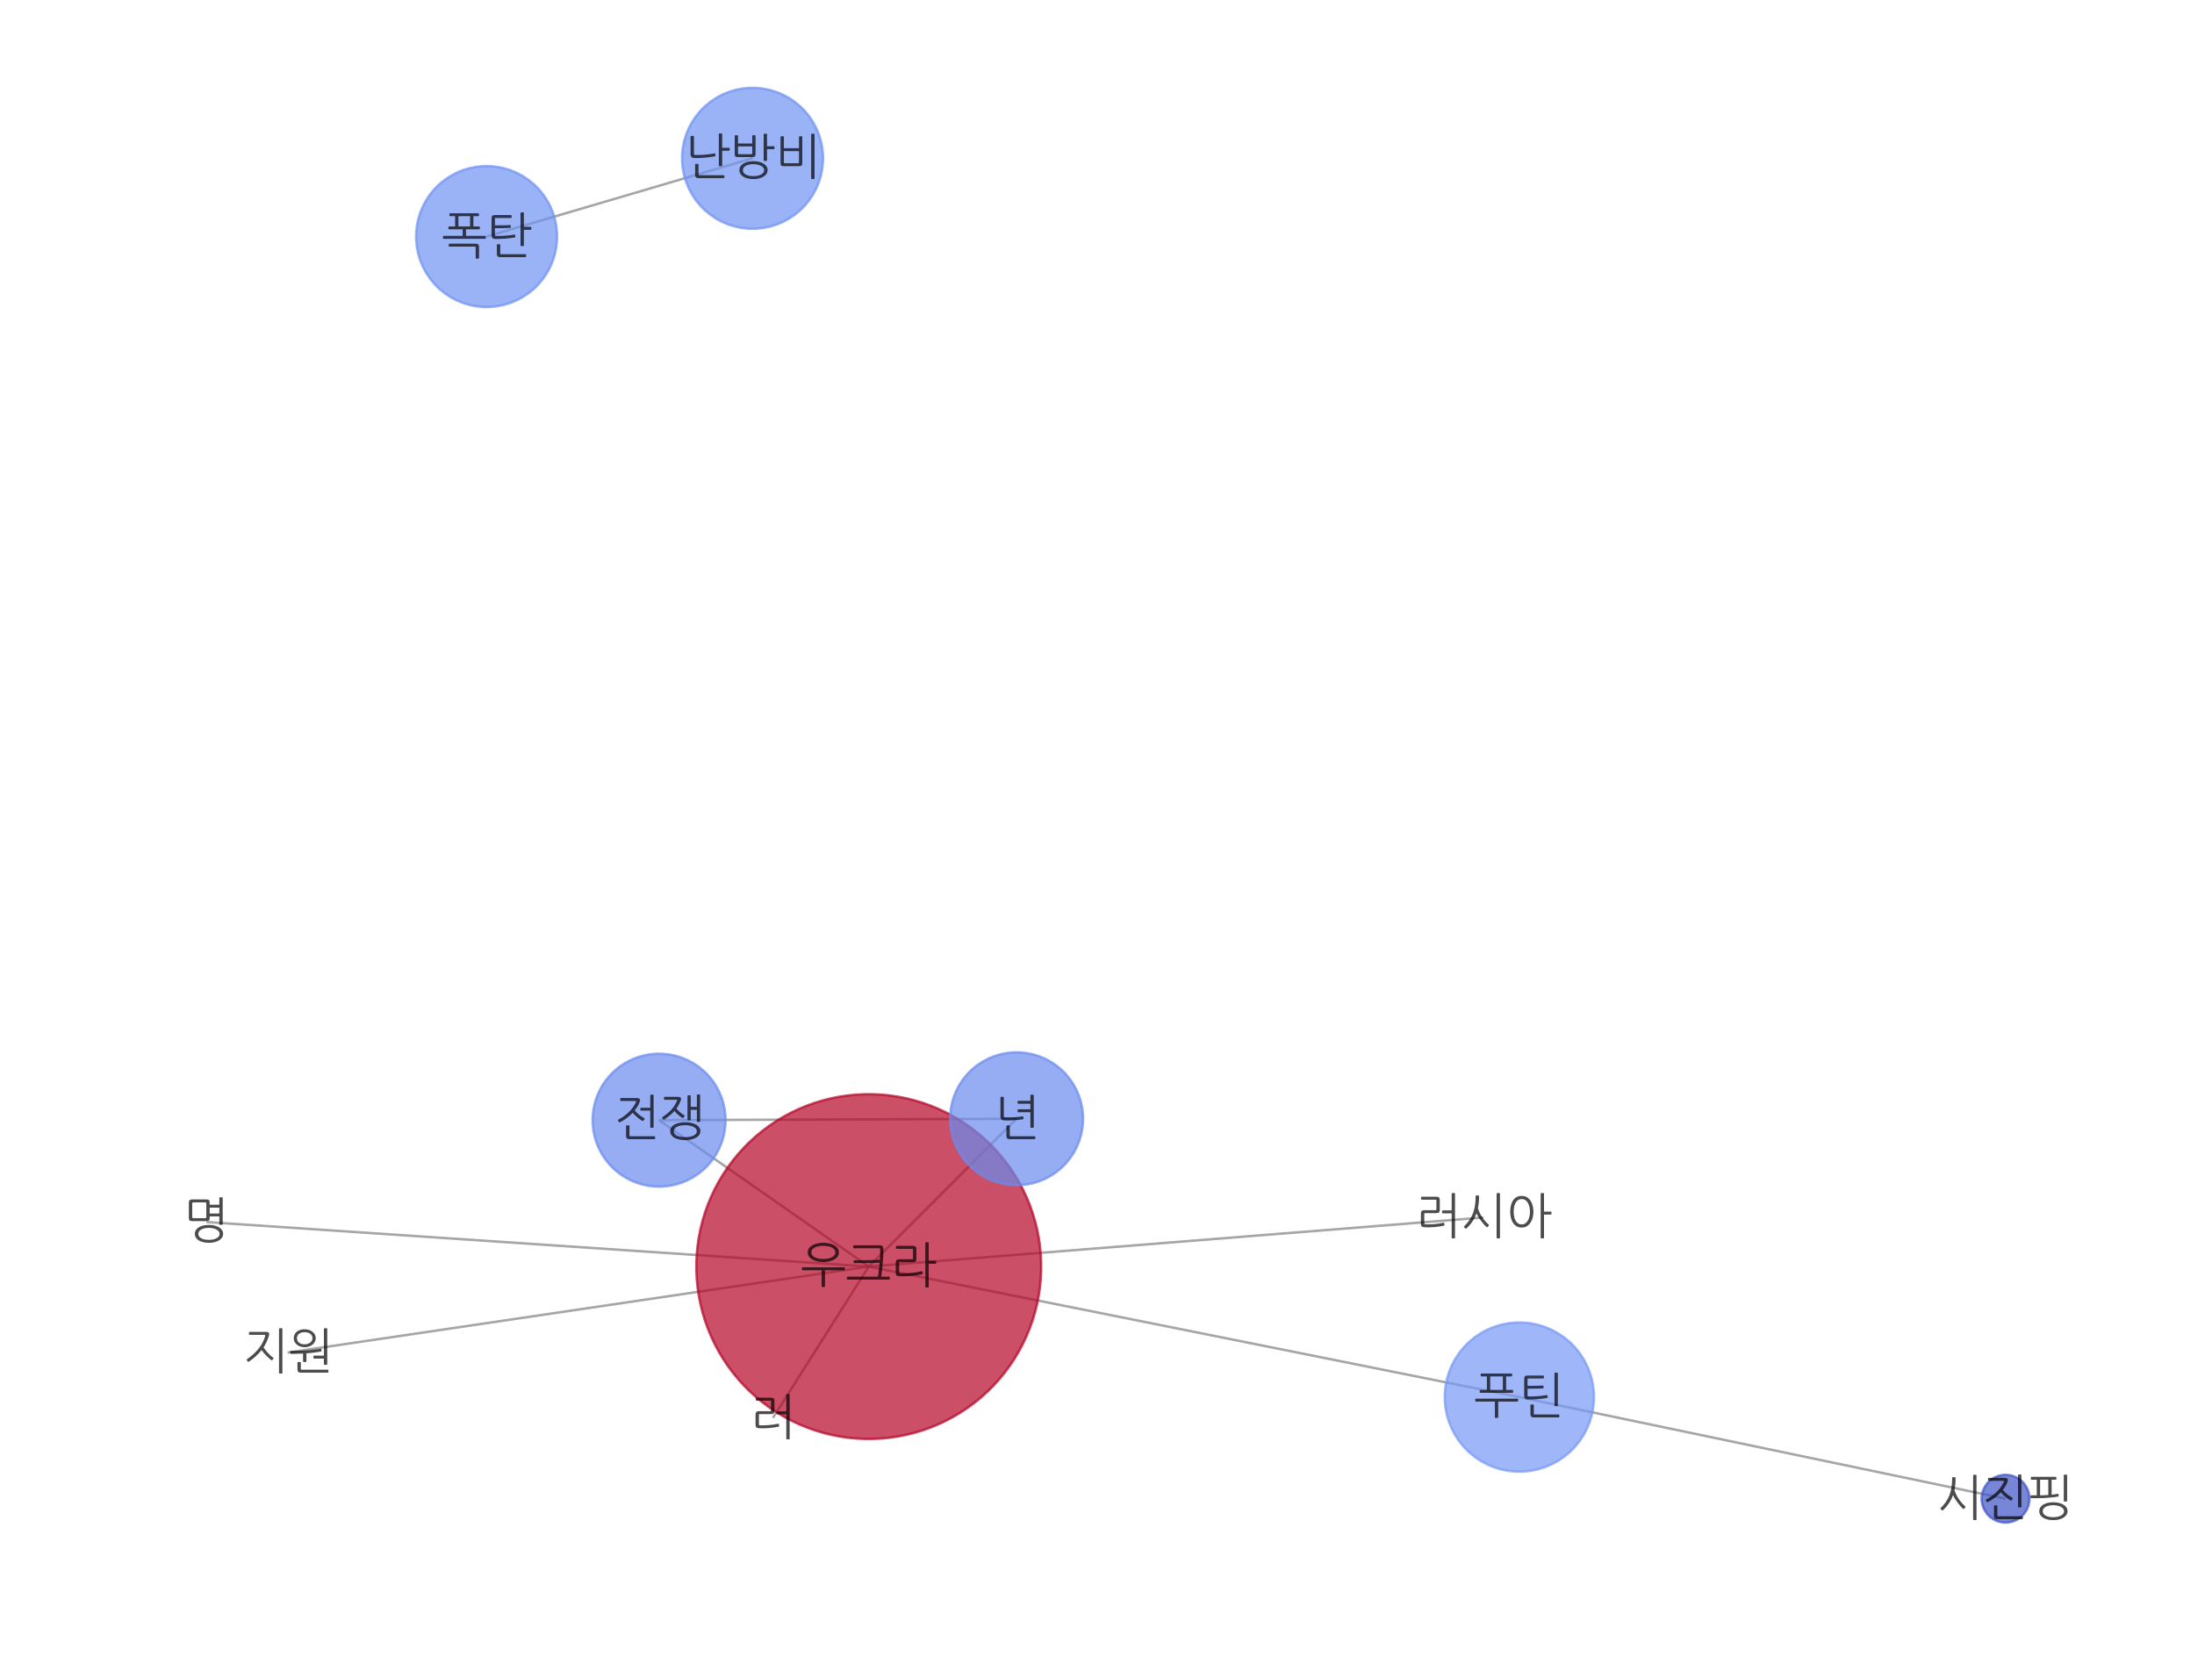

In [97]:
G = nx.Graph()
ar = (df['items']); G.add_edges_from(ar)
pr = nx.pagerank(G)
nsize = np.array([v for v in pr.values()])
nsize = 2000*(nsize-min(nsize)) / (max(nsize)- min(nsize))
pos = nx.spring_layout(G) #spring 레이아웃을 사용하기

plt.figure(figsize=(16,12)); plt.axis('off')
nx.draw_networkx(G, font_family='NanumGothic', font_size=20, pos=pos,\
                 node_color=list(pr.values()), node_size=nsize*10, alpha=0.7,\
                 edge_color='.5', cmap=plt.cm.coolwarm)
plt.savefig('네트워크 그래프_우크라이나.png', bbox_inches='tight')

           height     weight
count   98.000000  98.000000
mean   132.130612  31.536735
std     12.395954   9.699361
min    110.900000  17.200000
25%    122.975000  24.150000
50%    131.150000  28.950000
75%    140.725000  39.575000
max    163.000000  56.700000 



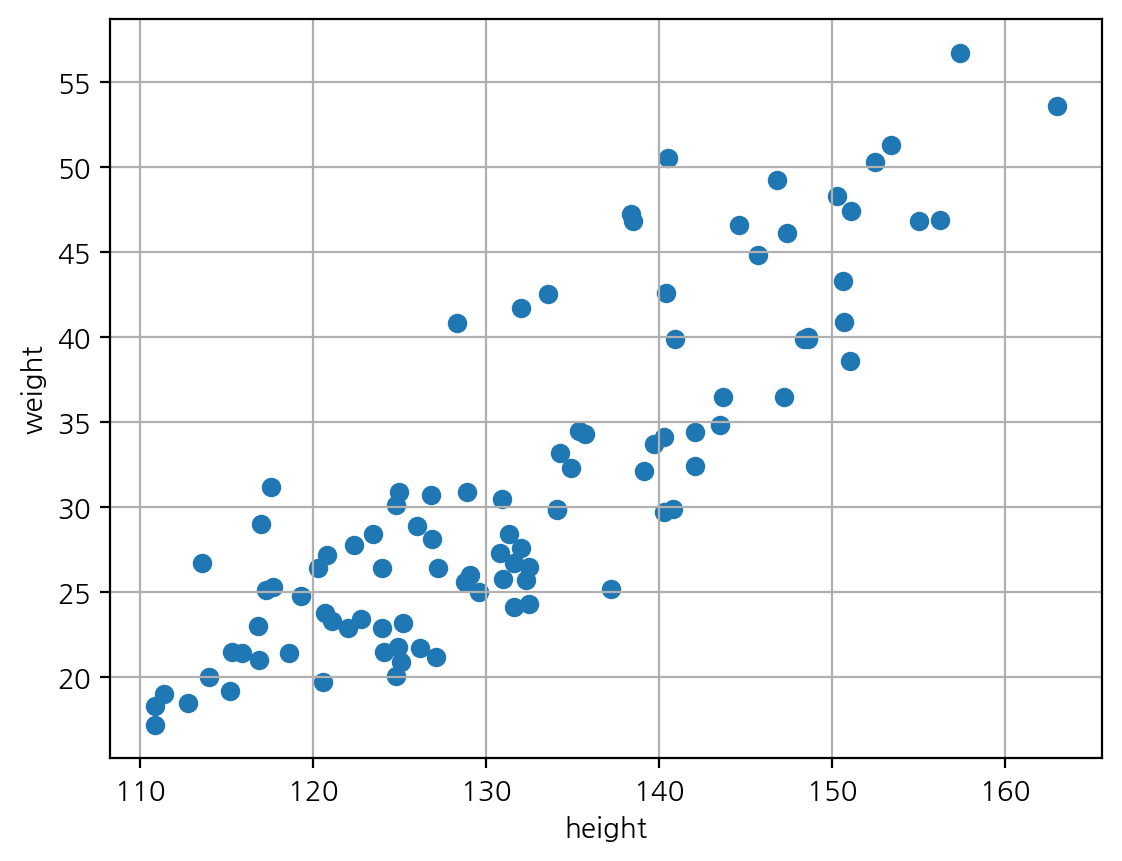

PearsonRResult(statistic=np.float64(0.8583011404409245), pvalue=np.float64(1.437544039843624e-29))


In [98]:
#예제 7-1 산점도와 상관계수
import pandas as pd
df = pd.DataFrame(pd.read_excel('/content/초등학교3학년_남자.xlsx'))

#데이터프레임 컬럼명 변경
df.columns = ['height','weight']
print(df.describe(),'\n')

import matplotlib.pyplot as plt
plt.scatter(df.height, df.weight)
plt.xlabel('height')
plt.ylabel('weight')
plt.grid()
plt.show()

import scipy.stats as stats
#피어슨 상관계수 검정
corr = stats.pearsonr(df.height, df.weight)
print(corr)

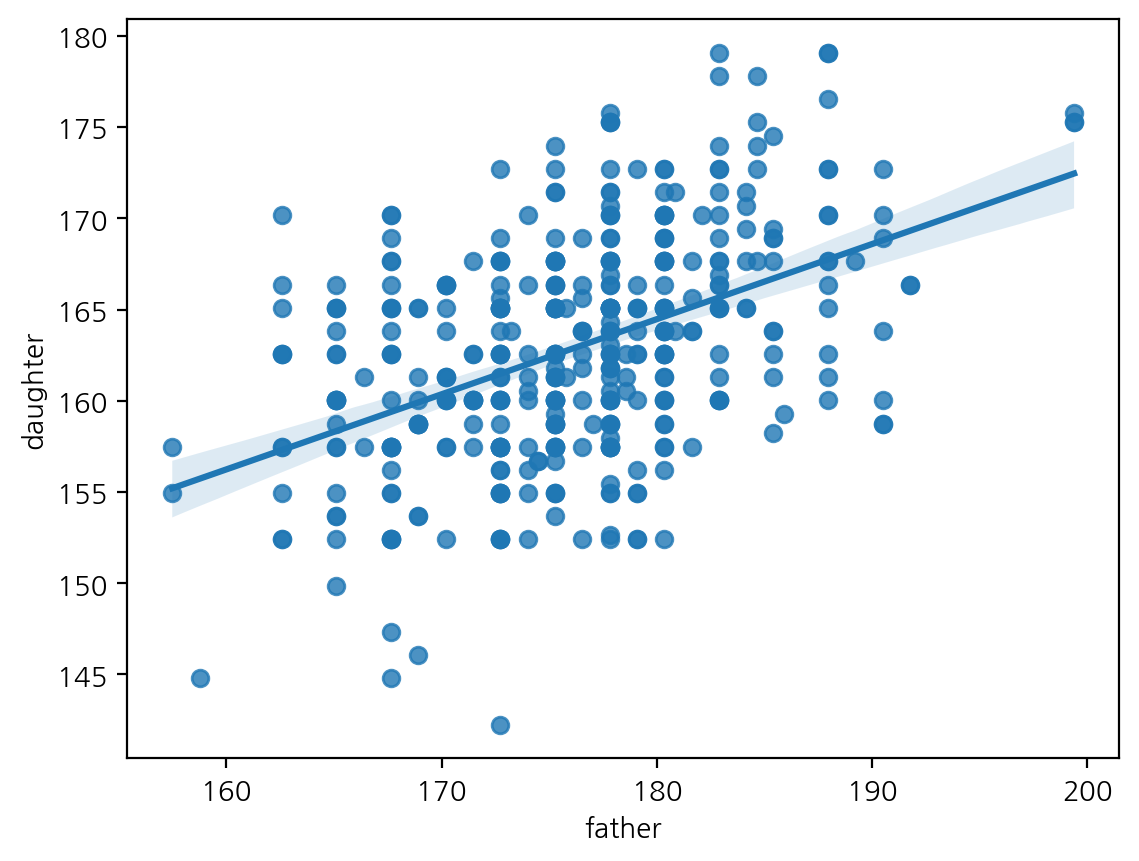

                            OLS Regression Results                            
Dep. Variable:            df.daughter   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     114.9
Date:                Tue, 17 Jun 2025   Prob (F-statistic):           6.36e-24
Time:                        15:22:38   Log-Likelihood:                -1340.1
No. Observations:                 433   AIC:                             2684.
Df Residuals:                     431   BIC:                             2692.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     90.3865      6.764     13.362      0.0

In [99]:
#예제7-2 단순회귀분석
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(pd.read_excel(r'/content/Galtons Height Data_딸.xlsx'))
df = 2.54*df

import seaborn as sns
sns.regplot(x=df.father, y=df.daughter)
plt.show()

from statsmodels.formula.api import ols
fit = ols('df.daughter ~ df.father', data=df).fit()
print(fit.summary())